# MirrorQATopo — Topological Boundary Experiment

Comparing `mode='full'` (all genuine qubits always paired) against
`mode='random'` (50:50 chance per even layer of f2f vs f2g outcome).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.transpiler import Target
from qiskit.quantum_info import Operator
from qiskit.circuit.library import CXGate
from qiskit_device_benchmarking.bench_code.mrb import MirrorQA, MirrorQATopo, QuantumAwesomeness
from qiskit_device_benchmarking.bench_code.mrb import TopoUtil
import os, random

SEED = 123
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

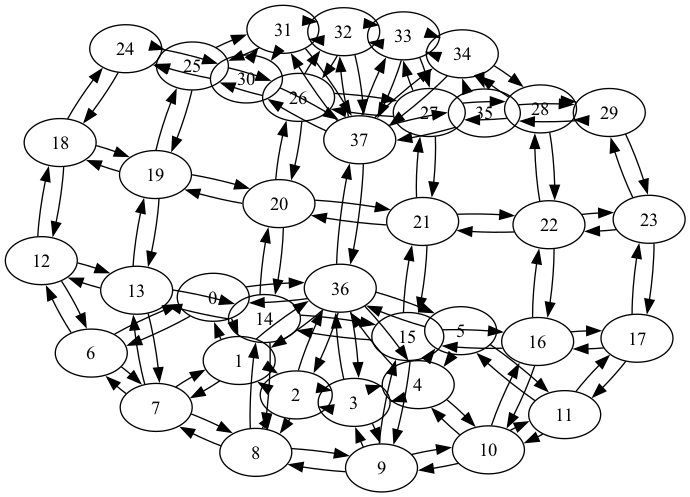

In [2]:
basis_gates = ["id", "h", "x", "y", "z", "rz", "cx"]
p2 = 5e-2 # 1e-3 (0.1%), 1e-2 (1%), 5e-2 (5%)
p1 = p2 / 10
rz_angle = np.pi / 2
# error rate for paper: 0.1, 1, 5%

shots = 1000
lengths = [2] + [4, 10, 20, 50, 100] # *** Change this for the heavy sin graph.
# 25, 30, 35, 40, 45) and 80
# lengths = [20] + [26, 30, 36, 40, 46, 50, 56, 60]
# lengths = [40, 50, 60, 70, 80, 90]
num_samples = 100 # 100 for the paper (original notebook: 20)
num_lengths = len(lengths)

# Coupling map: 4x4 genuine lattice + 2 fake boundary qubits (18 nodes total)
cmap = TopoUtil.makeCouple(6, 6, 2, 'ibm')
num_qubits = len(list(cmap.physical_qubits))  # 18
legit_qubits = 36  # indices 0-15 are genuine; 16, 17 are fake
TopoUtil.checkCouple(cmap)

In [3]:
target = Target.from_configuration(
    num_qubits=num_qubits,
    basis_gates=basis_gates,
    coupling_map=cmap, # Give it the coupling map that we just created.
    custom_name_mapping={
        "id": Operator(np.eye(2)),
        "h":  Operator(np.array([[1, 1], [1, -1]]) / np.sqrt(2)),
        "x":  Operator(np.array([[0, 1], [1, 0]])),
        "y":  Operator(np.array([[0, -1j], [1j, 0]])),
        "z":  Operator(np.array([[1, 0], [0, -1]])),
        "rz": Operator([[np.cos(rz_angle/2), -1j*np.sin(rz_angle/2)],
                         [-1j*np.sin(rz_angle/2), np.cos(rz_angle/2)]]),
        "cx": Operator(np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]])),
    },
)

noise_model = NoiseModel()
error_1q = depolarizing_error(p1, 1)
error_2q = depolarizing_error(p2, 2)
for gate in basis_gates:
    if gate in ["id", "h", "x", "y", "z", "rz"]:
        noise_model.add_all_qubit_quantum_error(error_1q, gate)
    elif gate == "cx":
        noise_model.add_all_qubit_quantum_error(error_2q, gate)

In [4]:
backend = AerSimulator(
    method="stabilizer",
    noise_model=noise_model if (p1 > 0 or p2 > 0) else None,
    target=target,
    max_parallel_threads=0,
    max_parallel_experiments=0,
    seed_simulator=SEED,
)

Until above, everything is the same.<br/>
When we make the experiment object, give it 'full' or 'random' for `sampling_algorithm`.<br/>
For MirrorQATopo, there will be another parameter more than `sampling_algorithm`. <br/><br/>
The basic value for `sampling_algorithm` is `topo`, and within `topo`, there are two modes, either `full` or `random`. Choose either of those keywords.

```
makeCouple(num_rows, num_cols)
    └─▶ CouplingMap (genuine + fake edges)
            │
            ▼
    Target / Backend  (simulator knows about all 18 qubits)
            │
            ▼ MirrorQATopo(range(16), ...)
    _set_distribution_options()
    line 264: coupling_map.reduce(physical_qubits)   ← strips fake edges
            │
            ▼
    TopoSampler._select_edges_topo()
    — builds left/right columns algebraically from corners[1]+1
    — never reads fake-qubit connections from the coupling map
```

In [5]:
exp = MirrorQATopo(
    range(legit_qubits),
    lengths=lengths,
    sampling_algorithm='topo',
    mode='random', # 'full': This mode is the same with NewSampler's behaviour.
    backend=backend,
    two_qubit_gate_density=0.5,
    num_samples=num_samples,
    initial_entangling_angle=np.pi / 2,
    seed=SEED,
)
exp.set_run_options(shots=shots)
rb_data = exp.run()
print(rb_data.job_ids)

for i in range(len(exp._pairs)):
    length = lengths[i % num_lengths]
    sample = i // num_lengths
    print(f"Circuit {i:3d} | length={length:3d}, sample={sample:2d}: "
          f"{len(exp._pairs[i])} pairs — {exp._pairs[i]}")

['740a5370-c57a-461a-98bc-c5b57562da84']
Circuit   0 | length=  2, sample= 0: 17 pairs — [(6, 12), (21, 22), (8, 9), (33, 27), (13, 14), (4, 5), (17, 23), (10, 11), (19, 20), (28, 29), (15, 16), (3, 2), (34, 35), (1, 7), (24, 18), (30, 31), (25, 26)]
Circuit   1 | length=  4, sample= 0: 17 pairs — [(6, 12), (21, 22), (8, 9), (33, 27), (13, 14), (4, 5), (17, 23), (10, 11), (19, 20), (28, 29), (15, 16), (3, 2), (34, 35), (1, 7), (24, 18), (30, 31), (25, 26)]
Circuit   2 | length= 10, sample= 0: 17 pairs — [(24, 30), (29, 35), (20, 26), (8, 9), (27, 28), (16, 10), (7, 1), (15, 14), (33, 32), (18, 19), (31, 25), (17, 23), (5, 11), (22, 21), (2, 3), (13, 12), (6, 0)]
Circuit   3 | length= 20, sample= 0: 17 pairs — [(12, 13), (10, 9), (25, 19), (26, 32), (4, 5), (17, 11), (1, 2), (27, 33), (16, 15), (18, 24), (22, 21), (8, 7), (14, 20), (23, 29), (0, 6), (28, 34), (30, 31)]
Circuit   4 | length= 50, sample= 0: 18 pairs — [(15, 21), (24, 30), (29, 35), (31, 32), (23, 22), (25, 26), (28, 27), 

**Validation** — ground-truth outcome per circuit, derived from `exp._pairs` (sampler metadata, not MI).
- `f2f` if `len(pairs) == legit // 2` → all genuine qubits paired, nl–nr won the MWPM.
- `f2g` if `len(pairs) == legit // 2 − 1` → 2 genuine boundary qubits abandoned, nl/nr paired with boundary instead.

This oracle is **not** available to the bot — the bot can only see MI from measurement counts.

In [ ]:
all_legit = set(range(legit_qubits))                                                                        
                                                                                                              
print(f"{'Circuit':>7} | {'length':>6} | {'sample':>6} | {'outcome':>6} | {'pairs':>5} | abandoned")        
print("-" * 65)                                                                                             
for i, pairs in enumerate(exp._pairs):                                                                      
    length  = lengths[i % num_lengths]                  
    sample  = i // num_lengths                                                                              
    paired  = {q for p in pairs for q in p}
    singles = set(exp._singles[i])                                                                          
    abandoned = all_legit - paired - singles            
                                                                                                              
    outcome = 'f2f' if len(pairs) == legit_qubits // 2 else 'f2g'
    print(f"  {i:5d} | {length:6d} | {sample:6d} | {outcome:>6} | "                                         
          f"{len(pairs):5d} | {sorted(abandoned) if abandoned else '-'}")

Circuit | length | sample | outcome | pairs | abandoned
-----------------------------------------------------------------
      0 |     40 |      0 |    f2g |     7 | [0, 14]
      1 |     50 |      0 |    f2g |     7 | [3, 15]
      2 |     60 |      0 |    f2f |     8 | -
      3 |     70 |      0 |    f2f |     8 | -
      4 |     80 |      0 |    f2g |     7 | [3, 15]
      5 |     90 |      0 |    f2g |     7 | [1, 15]
      6 |    100 |      0 |    f2g |     7 | [1, 15]
      7 |     40 |      1 |    f2f |     8 | -
      8 |     50 |      1 |    f2f |     8 | -
      9 |     60 |      1 |    f2g |     7 | [3, 15]
     10 |     70 |      1 |    f2f |     8 | -
     11 |     80 |      1 |    f2g |     7 | [0, 14]
     12 |     90 |      1 |    f2g |     7 | [3, 15]
     13 |    100 |      1 |    f2f |     8 | -
     14 |     40 |      2 |    f2f |     8 | -
     15 |     50 |      2 |    f2f |     8 | -
     16 |     60 |      2 |    f2g |     7 | [0, 14]
     17 |     70 |      2

Circuit | length | sample | outcome | pairs | abandoned
-----------------------------------------------------------------
      0 |     20 |      0 |    f2f |     8 | -
      1 |     26 |      0 |    f2f |     8 | -
      2 |     30 |      0 |    f2f |     8 | -
      3 |     36 |      0 |    f2g |     7 | [1, 13]
      4 |     40 |      0 |    f2g |     7 | [0, 14]
      5 |     46 |      0 |    f2g |     7 | [2, 12]
      6 |     50 |      0 |    f2g |     7 | [3, 15]
      7 |     56 |      0 |    f2f |     8 | -
      8 |     60 |      0 |    f2f |     8 | -
      9 |     20 |      1 |    f2g |     7 | [3, 15]
     10 |     26 |      1 |    f2g |     7 | [0, 12]
     11 |     30 |      1 |    f2g |     7 | [1, 15]
     12 |     36 |      1 |    f2f |     8 | -
     13 |     40 |      1 |    f2g |     7 | [1, 15]
     14 |     46 |      1 |    f2f |     8 | -
     15 |     50 |      1 |    f2f |     8 | -
     16 |     56 |      1 |    f2g |     7 | [0, 14]
     17 |     60 |      1

**Standard analysis** — fit the effective-polarisation decay curve using `MirrorRBAnalysis`.

In [6]:
exp.analysis.set_options(analyzed_quantity="Effective Polarization")
analysis = exp.analysis.run(rb_data)

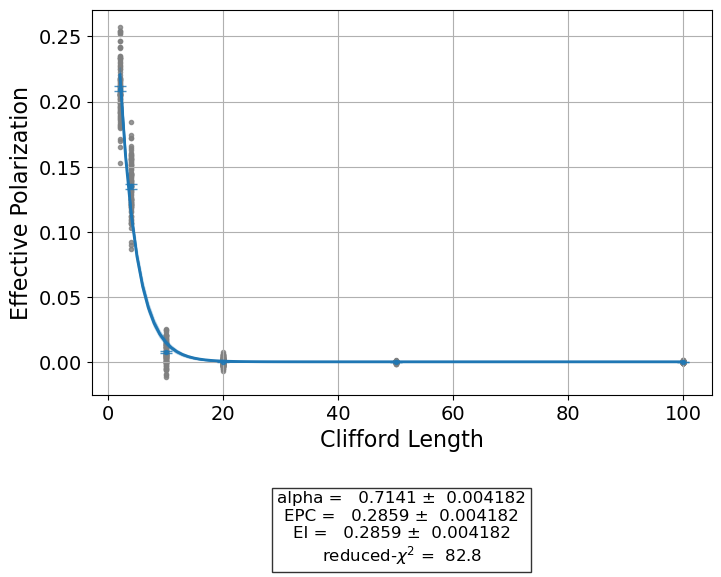

In [7]:
analysis.figure(0)

**MI analysis** — per-depth mutual information separated into *paired* (edge had an active CX in that circuit's first layer) vs *singles* (qubit had no 2Q partner).

`QuantumAwesomeness` takes the **genuine-only** coupling map — the fake boundary qubits (nl, nr) were never part of any circuit and must be excluded before computing MI.

/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype

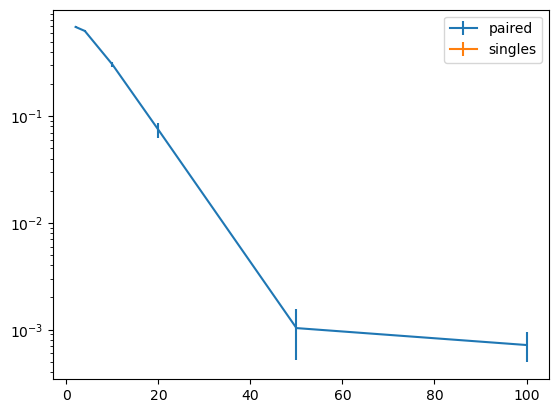

In [8]:
# [(j, k) for j, k in exp.backend.coupling_map if j < legit_qubits and k < legit_qubits]
# This can be easily written via qiskit.transpiler.CouplingMap.reduce().
# It will return the CouplingMap object, with the tuples (pairs) that we built.

legit_cmap = exp.backend.coupling_map.reduce(range(legit_qubits))
qa = QuantumAwesomeness(legit_cmap)

mi = qa.mutual_info(rb_data.data())
mmi = qa.mean_mutual_info(rb_data.data(), exp._pairs)

num_lengths = len(lengths)
ys = [[[] for _ in range(num_lengths)] for _ in range(2)]
yerrs = [[], []]

for p, pairtype in enumerate(["paired", "singles"]):
    for j, m in enumerate(mmi[pairtype]):
        if m is not np.nan:
            ys[p][j % num_lengths].append(m)
    for j in range(num_lengths):
        yerrs[p].append(np.std(ys[p][j]))
        ys[p][j] = np.mean(ys[p][j])

plt.errorbar(lengths, ys[0], yerr=yerrs[0], label="paired")
plt.errorbar(lengths, ys[1], yerr=yerrs[1], label="singles")
plt.yscale("log")
plt.legend()

### Bot!

In [9]:
import networkx as nx
from collections import defaultdict

# --- Helper: Determine TopoSampler mode from fake qubit connectivity ---
def get_topo_mode(topo_full, legit_qubits, fake_qubits):
    # topo_full: list of all MWPM pairs (tuples)
    # fake_qubits: set of fake qubit indices (e.g., {16, 17})
    # Returns: 'f2f' if fake qubits paired with each other, 'f2g' if paired with genuine
    fake_pairs = [p for p in topo_full if any(q in fake_qubits for q in p)]
    if not fake_pairs:
        return 'f2f'  # No fake qubits paired, all genuine paired
    # If both fake qubits are paired together, it's f2f
    for p in fake_pairs:
        if all(q in fake_qubits for q in p):
            return 'f2f'
    return 'f2g'

half = legit_qubits // 2
fake_qubits = set(range(legit_qubits, num_qubits))

bot_vs_topo_pairs = defaultdict(int)
bot_vs_topo_mode = defaultdict(int)
bot_vs_pairs_pairs = defaultdict(int)
topo_vs_pairs_ok = defaultdict(int)
total_by_len = defaultdict(int)

for i, info in enumerate(mi):
    length = lengths[i % num_lengths]
    sample = i // num_lengths

    # 1. TopoSampler MWPM (all pairs, incl. fake)
    topo_full = exp._topo_outcomes[i]
    topo_genuine = sorted(
        tuple(sorted((u, v)))
        for u, v in topo_full
        if u < legit_qubits and v < legit_qubits
    )
    topo_mode = get_topo_mode(topo_full, legit_qubits, fake_qubits)

    # 2. Bot guess (MI-MWPM)
    G = nx.Graph()
    for (u, v), w in info.items():
        G.add_edge(u, v, weight=w)
    raw_guess = nx.max_weight_matching(G, maxcardinality=False, weight="weight")
    bot_pairs = sorted(tuple(sorted(p)) for p in raw_guess)
    bot_mode = "f2f" if len(bot_pairs) == half else "f2g"

    matched_mi = [info[p] for p in bot_pairs if p in info]
    mean_mi = np.mean(matched_mi) if matched_mi else float("nan")

    # 3. exp._pairs cross-check
    pairs_truth = sorted(tuple(sorted(p)) for p in exp._pairs[i])
    pairs_mode = "f2f" if len(pairs_truth) == half else "f2g"

    # 4. Outcomes
    bot_exact = set(bot_pairs) == set(topo_genuine)
    bot_mode_ok = bot_mode == topo_mode
    tag = "EXACT" if bot_exact else ("MODE " if bot_mode_ok else "MISS ")

    bot_vs_topo_pairs[length] += int(bot_exact)
    bot_vs_topo_mode[length] += int(bot_mode_ok)
    bot_vs_pairs_pairs[length] += int(set(bot_pairs) == set(pairs_truth))
    topo_vs_pairs_ok[length] += int(set(topo_genuine) == set(pairs_truth))
    total_by_len[length] += 1

    print(
        f"[{i:3d}] L={length:3d}  sample={sample:3d}  topo={topo_mode}  bot={bot_mode}  [{tag}]  mean-MI={mean_mi:.4f}"
    )
    print(f"       Topo  : {topo_genuine}")
    print(f"       Bot   : {bot_pairs}")
    print()

# --- Summary table ---
print(
    "═══ Bot accuracy by circuit depth ═══════════════════════════════════════════════"
)
print(
    f"{'Length':>8} │ {'P(bot=topo)':>11} │ {'P(mode=topo)':>12} │ {'P(bot=pairs)':>12} │ {'P(topo=pairs)':>13} │ {'N':>5}"
)
print("─" * 70)
for length in lengths:
    t = total_by_len[length]
    print(
        f"{length:8d} │ {bot_vs_topo_pairs[length] / t:11.3f} │"
        f" {bot_vs_topo_mode[length] / t:12.3f} │"
        f" {bot_vs_pairs_pairs[length] / t:12.3f} │"
        f" {topo_vs_pairs_ok[length] / t:13.3f} │ {t:5d}"
    )

print()
print("P(bot=topo)   — bot pairs exactly match TopoSampler's MWPM [PRIMARY]")
print("P(mode=topo)  — bot predicts f2f/f2g correctly vs TopoSampler (using fake qubit connectivity)")
print("P(bot=pairs)  — bot pairs match exp._pairs (circuit oracle, secondary)")
print("P(topo=pairs) — TopoSampler MWPM agrees with exp._pairs (consistency check)")


[  0] L=  2  sample=  0  topo=f2g  bot=f2g  [EXACT]  mean-MI=0.6937
       Topo  : [(1, 7), (2, 3), (4, 5), (6, 12), (8, 9), (10, 11), (13, 14), (15, 16), (17, 23), (18, 24), (19, 20), (21, 22), (25, 26), (27, 33), (28, 29), (30, 31), (34, 35)]
       Bot   : [(1, 7), (2, 3), (4, 5), (6, 12), (8, 9), (10, 11), (13, 14), (15, 16), (17, 23), (18, 24), (19, 20), (21, 22), (25, 26), (27, 33), (28, 29), (30, 31), (34, 35)]

[  1] L=  4  sample=  0  topo=f2g  bot=f2g  [EXACT]  mean-MI=0.6145
       Topo  : [(1, 7), (2, 3), (4, 5), (6, 12), (8, 9), (10, 11), (13, 14), (15, 16), (17, 23), (18, 24), (19, 20), (21, 22), (25, 26), (27, 33), (28, 29), (30, 31), (34, 35)]
       Bot   : [(1, 7), (2, 3), (4, 5), (6, 12), (8, 9), (10, 11), (13, 14), (15, 16), (17, 23), (18, 24), (19, 20), (21, 22), (25, 26), (27, 33), (28, 29), (30, 31), (34, 35)]

[  2] L= 10  sample=  0  topo=f2g  bot=f2g  [EXACT]  mean-MI=0.3145
       Topo  : [(0, 6), (1, 7), (2, 3), (5, 11), (8, 9), (10, 16), (12, 13), (14, 15),

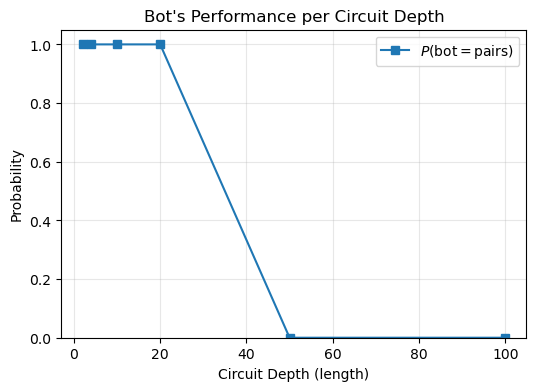

In [ ]:
# --- P(bot=pairs) vs circuit depth ---
lengths_sorted = sorted(lengths)
# p_bot_topo = [bot_vs_topo_pairs[L] / total_by_len[L] for L in lengths_sorted]
p_bot_pairs = [bot_vs_pairs_pairs[L] / total_by_len[L] for L in lengths_sorted]

plt.figure(figsize=(6,4))
# plt.plot(lengths_sorted, p_bot_topo, marker='o', label=r'$P(\mathrm{bot}=\mathrm{topo})$')
plt.plot(lengths_sorted, p_bot_pairs, marker='s', label=r'$P(\mathrm{bot}=\mathrm{pairs})$')
plt.xlabel('Circuit Depth (length)')
plt.ylabel('Probability')
plt.title("Bot's Performance per Circuit Depth")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Job's done.

Now is the time for the actual graphs which demonstrates phase transition between different square lattice. Target is 4x4, 6x6, and 8x8, with 5% error rate.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.transpiler import Target
from qiskit.quantum_info import Operator
from qiskit.circuit.library import CXGate
from qiskit_device_benchmarking.bench_code.mrb import (
    # MirrorQA,
    MirrorQATopo,
    QuantumAwesomeness,
)
from qiskit_device_benchmarking.bench_code.mrb import TopoUtil
import os, random

In [ ]:
SEED = 123
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
basis_gates = ["id", "h", "x", "y", "z", "rz", "cx"]
p2 = 5e-2  # 1e-3 (0.1%), 1e-2 (1%), 5e-2 (5%)
p1 = p2 / 10
rz_angle = np.pi / 2
# error rate for paper: 0.1, 1, 5%

shots = 1000
# Adjust l based on the perference
lengths = [2] + [4, 10, 20, 50, 100]
# lengths = [20] + [26, 30, 36, 40, 46, 50, 56, 60]
num_samples = 100  # 100 for the paper (started from 20)
num_lengths = len(lengths)

# Let's build a coupling map!
# nxn genuine lattice + 2 fake boundary qubits (18 nodes total)
n = 4 # 4x4, 6x6, and 8x8
cmap = TopoUtil.makeCouple(n, n, 2, "ibm")
num_qubits = len(list(cmap.physical_qubits))
legit_qubits = n * n
TopoUtil.checkCouple(cmap) # Print out the coupling map

In [ ]:
# Default setting was using stabilizer.
backend = AerSimulator(
    method="stabilizer",
    noise_model=noise_model if (p1 > 0 or p2 > 0) else None,
    target=target,
    max_parallel_threads=0,
    max_parallel_experiments=0,
    seed_simulator=SEED,
)

## For 4x4

In [ ]:
exp = MirrorQATopo(
    range(legit_qubits),
    lengths=lengths,
    sampling_algorithm="topo",
    mode="random",  # 'full': This mode is the same with NewSampler's behaviour.
    backend=backend,
    two_qubit_gate_density=0.5,
    num_samples=num_samples,
    initial_entangling_angle=np.pi / 2,
    seed=SEED,
)
exp.set_run_options(shots=shots)
rb_data = exp.run()
print(rb_data.job_ids)

for i in range(len(exp._pairs)):
    length = lengths[i % num_lengths]
    sample = i // num_lengths
    print(
        f"Circuit {i:3d} | length={length:3d}, sample={sample:2d}: "
        f"{len(exp._pairs[i])} pairs — {exp._pairs[i]}"
    )

## Extract the MI data

In [ ]:
exp.analysis.set_options(analyzed_quantity="Effective Polarization")
analysis = exp.analysis.run(rb_data)

In [ ]:
analysis.figure(0)

In [ ]:
# [(j, k) for j, k in exp.backend.coupling_map if j < legit_qubits and k < legit_qubits]
# This can be easily written via qiskit.transpiler.CouplingMap.reduce().
# It will return the CouplingMap object, with the tuples (pairs) that we built.

legit_cmap = exp.backend.coupling_map.reduce(range(legit_qubits))
qa = QuantumAwesomeness(legit_cmap)

mi = qa.mutual_info(rb_data.data())
mmi = qa.mean_mutual_info(rb_data.data(), exp._pairs)

num_lengths = len(lengths)
ys = [[[] for _ in range(num_lengths)] for _ in range(2)]
yerrs = [[], []]

for p, pairtype in enumerate(["paired", "singles"]):
    for j, m in enumerate(mmi[pairtype]):
        if m is not np.nan:
            ys[p][j % num_lengths].append(m)
    for j in range(num_lengths):
        yerrs[p].append(np.std(ys[p][j]))
        ys[p][j] = np.mean(ys[p][j])

plt.errorbar(lengths, ys[0], yerr=yerrs[0], label="paired")
plt.errorbar(lengths, ys[1], yerr=yerrs[1], label="singles")
plt.yscale("log")
plt.legend()

## (Again) Bot!

In [ ]:
import networkx as nx
from collections import defaultdict


# --- Helper: Determine TopoSampler mode from fake qubit connectivity ---
def get_topo_mode(topo_full, legit_qubits, fake_qubits):
    # topo_full: list of all MWPM pairs (tuples)
    # fake_qubits: set of fake qubit indices (e.g., {16, 17})
    # Returns: 'f2f' if fake qubits paired with each other, 'f2g' if paired with genuine
    fake_pairs = [p for p in topo_full if any(q in fake_qubits for q in p)]
    if not fake_pairs:
        return "f2f"  # No fake qubits paired, all genuine paired
    # If both fake qubits are paired together, it's f2f
    for p in fake_pairs:
        if all(q in fake_qubits for q in p):
            return "f2f"
    return "f2g"


half = legit_qubits // 2
fake_qubits = set(range(legit_qubits, num_qubits))

bot_vs_topo_pairs = defaultdict(int)
bot_vs_topo_mode = defaultdict(int)
bot_vs_pairs_pairs = defaultdict(int)
topo_vs_pairs_ok = defaultdict(int)
total_by_len = defaultdict(int)

for i, info in enumerate(mi):
    length = lengths[i % num_lengths]
    sample = i // num_lengths

    # 1. TopoSampler MWPM (all pairs, incl. fake)
    topo_full = exp._topo_outcomes[i]
    topo_genuine = sorted(
        tuple(sorted((u, v)))
        for u, v in topo_full
        if u < legit_qubits and v < legit_qubits
    )
    topo_mode = get_topo_mode(topo_full, legit_qubits, fake_qubits)

    # 2. Bot guess (MI-MWPM)
    G = nx.Graph()
    for (u, v), w in info.items():
        G.add_edge(u, v, weight=w)
    raw_guess = nx.max_weight_matching(G, maxcardinality=False, weight="weight")
    bot_pairs = sorted(tuple(sorted(p)) for p in raw_guess)
    bot_mode = "f2f" if len(bot_pairs) == half else "f2g"

    matched_mi = [info[p] for p in bot_pairs if p in info]
    mean_mi = np.mean(matched_mi) if matched_mi else float("nan")

    # 3. exp._pairs cross-check
    pairs_truth = sorted(tuple(sorted(p)) for p in exp._pairs[i])
    pairs_mode = "f2f" if len(pairs_truth) == half else "f2g"

    # 4. Outcomes
    bot_exact = set(bot_pairs) == set(topo_genuine)
    bot_mode_ok = bot_mode == topo_mode
    tag = "EXACT" if bot_exact else ("MODE " if bot_mode_ok else "MISS ")

    bot_vs_topo_pairs[length] += int(bot_exact)
    bot_vs_topo_mode[length] += int(bot_mode_ok)
    bot_vs_pairs_pairs[length] += int(set(bot_pairs) == set(pairs_truth))
    topo_vs_pairs_ok[length] += int(set(topo_genuine) == set(pairs_truth))
    total_by_len[length] += 1

    print(
        f"[{i:3d}] L={length:3d}  sample={sample:3d}  topo={topo_mode}  bot={bot_mode}  [{tag}]  mean-MI={mean_mi:.4f}"
    )
    print(f"       Topo  : {topo_genuine}")
    print(f"       Bot   : {bot_pairs}")
    print()

# --- Summary table ---
print(
    "═══ Bot accuracy by circuit depth ═══════════════════════════════════════════════"
)
print(
    f"{'Length':>8} │ {'P(bot=topo)':>11} │ {'P(mode=topo)':>12} │ {'P(bot=pairs)':>12} │ {'P(topo=pairs)':>13} │ {'N':>5}"
)
print("─" * 70)
for length in lengths:
    t = total_by_len[length]
    print(
        f"{length:8d} │ {bot_vs_topo_pairs[length] / t:11.3f} │"
        f" {bot_vs_topo_mode[length] / t:12.3f} │"
        f" {bot_vs_pairs_pairs[length] / t:12.3f} │"
        f" {topo_vs_pairs_ok[length] / t:13.3f} │ {t:5d}"
    )

print()
print("P(bot=topo)   — bot pairs exactly match TopoSampler's MWPM [PRIMARY]")
print(
    "P(mode=topo)  — bot predicts f2f/f2g correctly vs TopoSampler (using fake qubit connectivity)"
)
print("P(bot=pairs)  — bot pairs match exp._pairs (circuit oracle, secondary)")
print("P(topo=pairs) — TopoSampler MWPM agrees with exp._pairs (consistency check)")

In [ ]:
# --- P(bot=pairs) vs circuit depth ---
lengths_sorted = sorted(lengths)
# p_bot_topo = [bot_vs_topo_pairs[L] / total_by_len[L] for L in lengths_sorted]
p_bot_pairs = [bot_vs_pairs_pairs[L] / total_by_len[L] for L in lengths_sorted]

plt.figure(figsize=(6, 4))
# plt.plot(lengths_sorted, p_bot_topo, marker='o', label=r'$P(\mathrm{bot}=\mathrm{topo})$')
plt.plot(
    lengths_sorted, p_bot_pairs, marker="s", label=r"$P(\mathrm{bot}=\mathrm{pairs})$"
)
plt.xlabel("Circuit Depth (length)")
plt.ylabel("Probability")
plt.title("Bot's Performance per Circuit Depth")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()